### Autoregressive model
- Are class of models that genereate data points in a sequnece by conditioning each new point on the previously geneareted points.

The transformer decoder is autoregressive at inference time and non autoregressive at training time.

**Transformer as an Autoregresive Model**
----------------
*Training*
|SN|English sentence|Nepali sentence|
|-|-|-|
|1|How are you|तपाई लाई कस्ताे छ|
|2|Congratualations|बधाई छ|
|3|Thank you|धन्यवाद|

---------------
Inference Query sentence->I am fine\
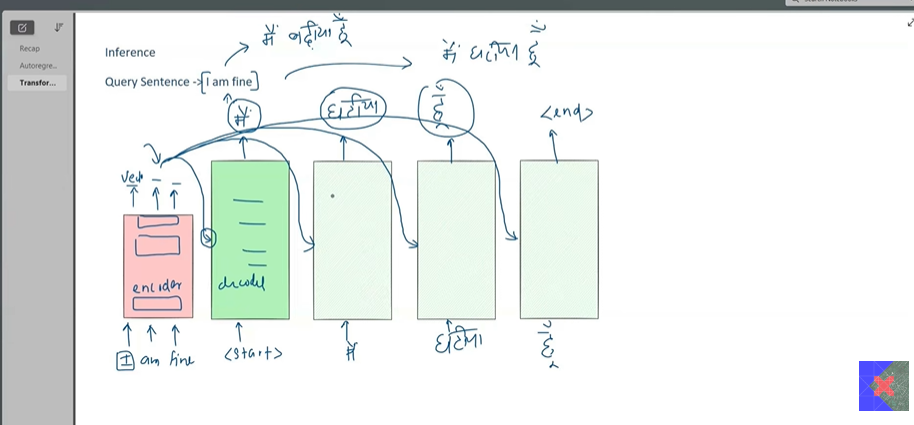

This shows the autoregressive nature of the model during the inference time
Now during the training time


Here feature forcing will be done. That is even if the decoder has given the wrong output we give the correct data in the next step of the decoder.

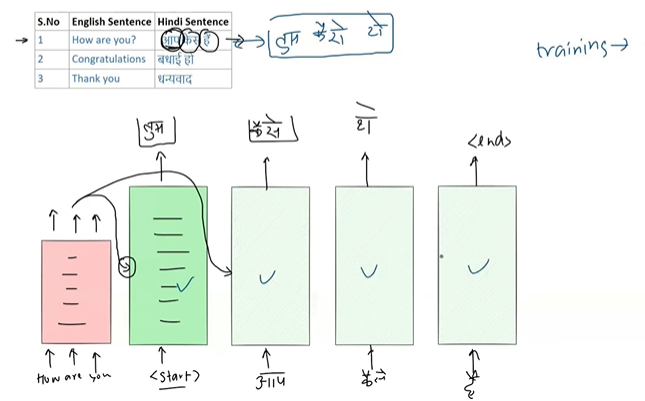

But the autoregressive nature makes the model too slow that is the serial operations being done(decoder being operated n times).

**The problem in parellelizing**
- The solution we can call the masked multi head attention.
- Let for simplicity it be a self attention block
- During the training we put all the training data in the self attention block(not serially)
- We do the encoding of the output data of the datasets (i.e output embedding followed by the postional endcoding)
- Then sending to the self attention block. 
- 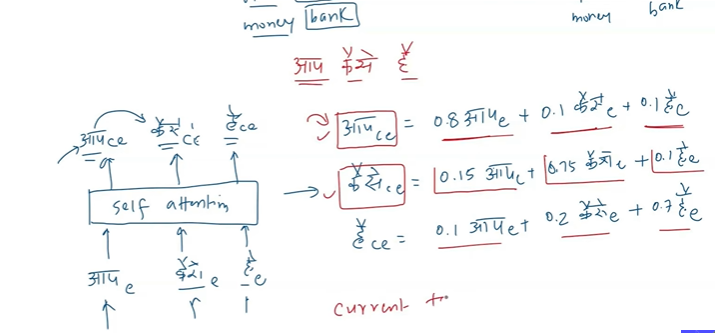
- we are using the future token value thus cannot be used in the inference but training and inference cannot be different

**The solution**
- We find the key query value then we do the dot product of the query and key value and then we find the matrix which has the attention score and do the scaling then we do the softmax
- Then we take the weights from the softmax and then find the contextual embeddings.
- We may not have the future data during inference time
- thus we do make the weights that we muiltiply zero.
- 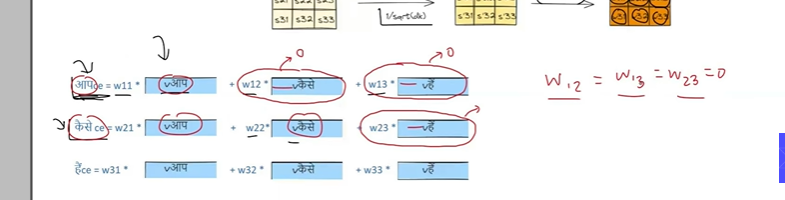
- We add the new matrix called the mask matrix with the -infinty value at the postion where we need the zero.
- Thus the softmax of those -ininfity will be zero
- Thus we have the mask
- That we for the last word all the previous are used but for the first word we use only what we have.
- That is autoregressive here.
